In [1]:
import sys
sys.path.append('/app')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices,
                generate_cascading_receptors,
                generate_targeted_receptors,
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap)
from run import initialize,train,test

In [2]:
n_units=3
k_sub = 5
n_families = 1
N_train = 2**16
N_test = 2**14
CONF = {
        "n_units": n_units,
        "n_families": n_families,
        "latent_dim": 3,
        "k_sub": k_sub,
        "batch_size": N_train,
        "epochs": 5000,
        "lr": 0.05,
        "cov_weight":10.,
        "n_bins":2,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)],dtype=torch.long), # size must be smaller or equal to n_units
        "init_means":[np.random.randint(1,8) for _ in range(n_families)], # size must be n_families
        "shape_sigma": 1.,
        "tolerant":False, # set whether we want tolerance for heteromers on the covariance loss
        "optimizer":"Adam",
        "momentum":0.9,
        "exact_loss":True,
        "temperature":0.1
    }
n_sensors = np.arange(1,10,1)

In [ ]:
# --- Setup Constants ---
k_sub = 5
n_sensors = np.arange(1, 10, 1)
N_train, N_test = 2**16, 2**14

# Define the "base" configurations for each of your 4 experimental groups
# Each tuple is: (label, fixed_n_units_or_None, function_to_gen_indices)
# If fixed_n_units is None, it means n_units varies with n_sensor
experiment_setups = [
    ("Default", None, lambda nu, ns: torch.tensor([[i for _ in range(k_sub)] for i in range(nu)], dtype=torch.long)),
    ("H2", 2, lambda nu, ns: generate_cascading_receptors(n_units=nu, k_sub=k_sub, n_sensors=ns)),
    ("H3", 3, lambda nu, ns: generate_cascading_receptors(n_units=nu, k_sub=k_sub, n_sensors=ns)),
    ("H4", 4, lambda nu, ns: generate_cascading_receptors(n_units=nu, k_sub=k_sub, n_sensors=ns)),
]

# Global results containers
all_test_results = []
all_train_stats = []

for label, fixed_units, gen_func in experiment_setups:
    current_group_test = []
    current_group_train = []
    
    print(f"Running experiment group: {label}")
    
    for n_sensor in n_sensors:
        # 1. Determine n_units: either fixed (2,3,4) or dynamic (matching n_sensor)
        n_units_val = fixed_units if fixed_units is not None else n_sensor
        
        # 2. Update Configuration
        CONF.update({
            "n_units": n_units_val,
            "receptor_indices": gen_func(n_units_val, n_sensor),
            "batch_size": N_train
        })
        
        # 3. Initialize and Run
        env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False)
        
        train_out = train(CONF, env, rec, loss_fn, optimize)
        test_out = test(CONF, env, rec, loss_fn, optimize, N_samples=N_test, indices=CONF['receptor_indices'])
        
        current_group_train.append(train_out)
        current_group_test.append(test_out)
        
    all_train_stats.append(current_group_train)
    all_test_results.append(current_group_test)

# Convert to final arrays for analysis
all_test_results_arr = np.array(all_test_results)

In [4]:
all_test_results_arr = np.load('../../data/bin/ent_test.npy')

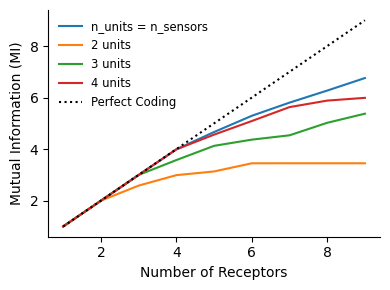

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))
labels = ['n_units = n_sensors', '2 units', '3 units', '4 units']

# all_test_results_arr shape: (4, 9, N_test_samples) 
# We average over the last dimension (the test samples)
for i in range(len(labels)):
    # Calculate mean across the N_test dimension
    mean_mi = np.mean(all_test_results_arr[i], axis=1) 
    ax.plot(n_sensors, mean_mi, label=labels[i])

# Plot the identity line (perfect coding)
ax.plot(n_sensors, n_sensors, color='black', linestyle=':', label='Perfect Coding')

ax.set_xlabel('Number of Receptors')
ax.set_ylabel('Mutual Information (MI)')
ax.legend(fontsize='small', frameon=False)

# Optional: clean up the top/right spines for a professional look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('../../data/fig/MI_sensors.svg', transparent=True, bbox_inches='tight')
plt.show()

# More complex environment

In [ ]:
n_units=3
k_sub = 5
n_families = 10
N_train = 2**16
N_test = 2**14
CONF = {
        "n_units": n_units,
        "n_families": n_families,
        "latent_dim": 10,
        "k_sub": k_sub,
        "batch_size": N_train,
        "epochs": 5000,
        "lr": 0.05,
        "cov_weight":10.,
        "n_bins":2,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)],dtype=torch.long), # size must be smaller or equal to n_units
        "init_means":[np.random.randint(1,8) for _ in range(n_families)], # size must be n_families
        "shape_sigma": 0.28,
        "tolerant":False, # set whether we want tolerance for heteromers on the covariance loss
        "optimizer":"Adam",
        "momentum":0.9,
        "exact_loss":True,
        "temperature":0.1
    }
n_sensors = np.arange(1,10,1)

In [ ]:
# --- Setup Constants ---
k_sub = 5
n_sensors = np.arange(1, 10, 1)
N_train, N_test = 2**16, 2**14

# Define the "base" configurations for each of your 4 experimental groups
# Each tuple is: (label, fixed_n_units_or_None, function_to_gen_indices)
# If fixed_n_units is None, it means n_units varies with n_sensor
experiment_setups = [
    ("Default", None, lambda nu, ns: torch.tensor([[i for _ in range(k_sub)] for i in range(nu)], dtype=torch.long)),
    ("H2", 2, lambda nu, ns: generate_cascading_receptors(n_units=nu, k_sub=k_sub, n_sensors=ns)),
    ("H3", 3, lambda nu, ns: generate_cascading_receptors(n_units=nu, k_sub=k_sub, n_sensors=ns)),
    ("H4", 4, lambda nu, ns: generate_cascading_receptors(n_units=nu, k_sub=k_sub, n_sensors=ns)),
]

# Global results containers
all_test_results = []
all_train_stats = []

for label, fixed_units, gen_func in experiment_setups:
    current_group_test = []
    current_group_train = []
    
    print(f"Running experiment group: {label}")
    
    for n_sensor in n_sensors:
        # 1. Determine n_units: either fixed (2,3,4) or dynamic (matching n_sensor)
        n_units_val = fixed_units if fixed_units is not None else n_sensor
        
        # 2. Update Configuration
        CONF.update({
            "n_units": n_units_val,
            "receptor_indices": gen_func(n_units_val, n_sensor),
            "batch_size": N_train
        })
        
        # 3. Initialize and Run
        env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False)
        
        train_out = train(CONF, env, rec, loss_fn, optimize)
        test_out = test(CONF, env, rec, loss_fn, optimize, N_samples=N_test, indices=CONF['receptor_indices'])
        
        current_group_train.append(train_out)
        current_group_test.append(test_out)
        
    all_train_stats.append(current_group_train)
    all_test_results.append(current_group_test)

# Convert to final arrays for analysis
all_test_results_arr = np.array(all_test_results)

In [10]:
all_test_results_arr = np.load('../../data/bin/ent_test_Nfams.npy')

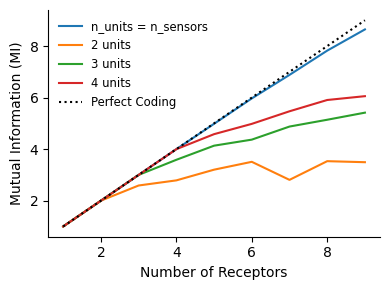

In [11]:
fig, ax = plt.subplots(figsize=(4, 3))
labels = ['n_units = n_sensors', '2 units', '3 units', '4 units']

# all_test_results_arr shape: (4, 9, N_test_samples) 
# We average over the last dimension (the test samples)
for i in range(len(labels)):
    # Calculate mean across the N_test dimension
    mean_mi = np.mean(all_test_results_arr[i], axis=1) 
    ax.plot(n_sensors, mean_mi, label=labels[i])

# Plot the identity line (perfect coding)
ax.plot(n_sensors, n_sensors, color='black', linestyle=':', label='Perfect Coding')

ax.set_xlabel('Number of Receptors')
ax.set_ylabel('Mutual Information (MI)')
ax.legend(fontsize='small', frameon=False)

# Optional: clean up the top/right spines for a professional look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../../data/fig/MI_sensors_Nfams.svg', transparent=True, bbox_inches='tight')
plt.show()